# Problem 3 - Question 9(b): QAOA Ansatz Study

本 notebook 在 `q9_faster_qaoa.py` 的 JAX/JIT 加速基础上，比较四种 Ansatz：

1. **Standard QAOA**：每层共享一个 $\gamma_l$ 和一个 $\beta_l$；
2. **Multi-angle QAOA**：每条边使用独立 $\gamma_{ij,l}$，每个顶点使用独立 $\beta_{i,l}$；
3. **Warm-start QAOA**：从经典局部搜索解附近的量子态开始，并使用匹配该初态的 mixer；
4. **Hardware-efficient Ansatz**：局部 $R_Y$ 旋转与沿图边的 CZ 纠缠层。

研究目标不是寻找一个对所有图都最好的 Ansatz，而是比较它们的解质量、参数数、纠缠门数、优化成本与稳定性。所有测试图至少有 8 个顶点。

In [1]:
from time import perf_counter

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import tensorcircuit as tc
from IPython.display import display
from scipy.optimize import minimize

from Fast_QAOA import cut_value, reference_cut

K = tc.set_backend("jax")
plt.rcParams.update({"figure.figsize": (6.4, 3.4), "figure.dpi": 110})

P = 2
MAXITER = 60
MAXFUN = 120
SHOTS = 1000
SEEDS = (3, 11, 29)

print("TensorCircuit backend:", tc.backend.name)
print(f"p={P}, maxiter={MAXITER}, shots={SHOTS}, seeds={SEEDS}")

TensorCircuit backend: jax
p=2, maxiter=60, shots=1000, seeds=(3, 11, 29)


## 1. Graph suite

选择四类结构不同的图：低度规则二分图、稠密二分图、不规则随机图和含受挫奇环的 Petersen 图。图像尺寸刻意保持较小，但每个实例均不少于 8 个顶点。

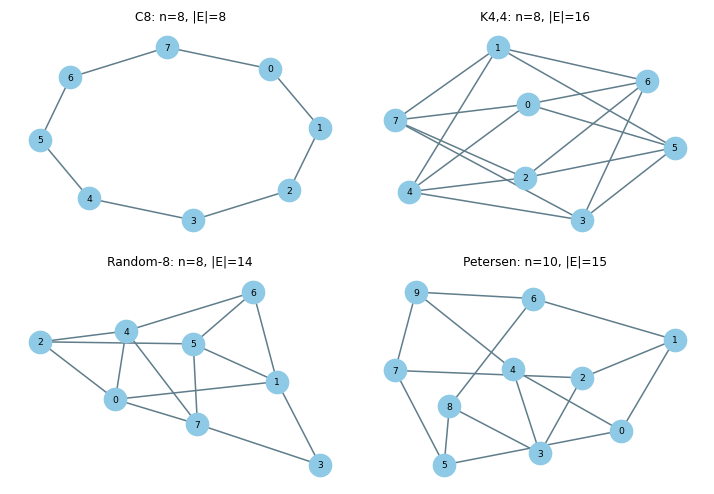

,graph,n,edges,bipartite,maxcut,reference
0,C8,8,8,True,8,exact
1,"K4,4",8,16,True,16,exact
2,Random-8,8,14,False,12,exact
3,Petersen,10,15,False,12,exact


In [2]:
GRAPHS = {
    "C8": nx.cycle_graph(8),
    "K4,4": nx.complete_bipartite_graph(4, 4),
    "Random-8": nx.erdos_renyi_graph(8, 0.35, seed=7),
    "Petersen": nx.petersen_graph(),
}

graph_rows = []
fig, axes = plt.subplots(2, 2, figsize=(6.6, 4.6))
for axis, (name, graph) in zip(axes.flat, GRAPHS.items()):
    graph = nx.convert_node_labels_to_integers(graph)
    GRAPHS[name] = graph
    optimum, reference_kind = reference_cut(graph)
    graph_rows.append({
        "graph": name,
        "n": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "bipartite": nx.is_bipartite(graph),
        "maxcut": optimum,
        "reference": reference_kind,
    })
    position = nx.spring_layout(graph, seed=4)
    nx.draw_networkx(
        graph, position, ax=axis, node_size=210, font_size=6,
        node_color="#8ecae6", edge_color="#607d8b", width=1.0,
    )
    axis.set_title(f"{name}: n={graph.number_of_nodes()}, |E|={graph.number_of_edges()}", fontsize=8)
    axis.axis("off")

plt.tight_layout()
plt.show()
display(pd.DataFrame(graph_rows))

## 2. Ansatz definitions

### 2.1 Standard QAOA

$$U_C(\gamma_l)=\prod_{(i,j)\in E}e^{-i\gamma_l C_{ij}},\qquad U_B(\beta_l)=\prod_i e^{-i\beta_lX_i}.$$

参数数为 $2p$，逻辑 CNOT 数约为 $2p|E|$。

### 2.2 Multi-angle QAOA

$$U_C=\prod_{(i,j)\in E}e^{-i\gamma_{ij,l}C_{ij}},\qquad U_B=\prod_i e^{-i\beta_{i,l}X_i}.$$

参数数增加为 $p(|E|+|V|)$；CNOT 数与 Standard 相同，但经典优化维数显著增加。

### 2.3 Warm-start QAOA

先用 `one_exchange` 得到经典 bitstring，并以 $\epsilon=0.15$ 平滑为 $x_i\in\{\epsilon,1-\epsilon\}$。初态为

$$\bigotimes_i\left(\sqrt{1-x_i}|0\rangle+\sqrt{x_i}|1\rangle\right),$$

通过 $R_Y(2\arcsin\sqrt{x_i})$ 制备。mixer 采用以该初态为基态的旋转轴，而不是直接沿用普通 $X$-mixer。

### 2.4 Hardware-efficient Ansatz

使用 $(p+1)n$ 个独立 $R_Y$ 参数，并在每层沿原图边施加 CZ。它通常更贴近硬件连接，但不再具有标准 QAOA 的严格交替算符结构。

In [3]:
ANSATZES = ("Standard", "Multi-angle", "Warm-start", "Hardware-efficient")


def cost_vector(n, edges):
    values = np.empty(1 << n, dtype=np.float32)
    for integer in range(1 << n):
        bits = format(integer, f"0{n}b")
        values[integer] = cut_value(bits, edges)
    return values


def warm_start_angles(graph, epsilon=0.15, seed=7, restarts=20):
    # A single local-search start may be poor, so keep the best of several
    # inexpensive classical restarts before constructing the quantum state.
    classical_value, partition = -1, None
    for trial in range(restarts):
        value, candidate = nx.algorithms.approximation.maxcut.one_exchange(
            graph, seed=seed + trial
        )
        if value > classical_value:
            classical_value, partition = value, candidate
    _, ones = partition
    classical_bits = np.zeros(graph.number_of_nodes(), dtype=int)
    classical_bits[list(ones)] = 1
    probabilities = np.where(classical_bits == 1, 1 - epsilon, epsilon)
    theta = np.arcsin(np.sqrt(probabilities))
    return theta, classical_bits, classical_value


def greedy_edge_colors(graph):
    line_graph = nx.line_graph(graph)
    if line_graph.number_of_nodes() == 0:
        return 0
    coloring = nx.coloring.greedy_color(line_graph, strategy="largest_first")
    return max(coloring.values()) + 1


def compile_ansatz(graph, ansatz, p):
    n = graph.number_of_nodes()
    edges = tuple(graph.edges())
    m = len(edges)
    costs_np = cost_vector(n, edges)
    costs = jnp.asarray(costs_np)
    edge_colors = greedy_edge_colors(graph)
    warm_theta_np, warm_bits, warm_classical_cut = warm_start_angles(graph)
    warm_theta = jnp.asarray(warm_theta_np)

    if ansatz in {"Standard", "Warm-start"}:
        parameter_count = 2 * p
        entangling_gates = 2 * p * m
    elif ansatz == "Multi-angle":
        parameter_count = p * (m + n)
        entangling_gates = 2 * p * m
    elif ansatz == "Hardware-efficient":
        parameter_count = (p + 1) * n
        entangling_gates = p * m
    else:
        raise ValueError(ansatz)

    if ansatz in {"Standard", "Multi-angle"}:
        depth_estimate = 1 + p * (3 * edge_colors + 1)
    elif ansatz == "Warm-start":
        depth_estimate = 1 + p * (3 * edge_colors + 3)
    else:
        depth_estimate = 2 + p * (edge_colors + 1)

    def probabilities(params):
        circuit = tc.Circuit(n)

        if ansatz == "Warm-start":
            for qubit in range(n):
                circuit.ry(qubit, theta=2.0 * warm_theta[qubit])
        else:
            for qubit in range(n):
                circuit.h(qubit)

        if ansatz == "Standard":
            gammas, betas = params[:p], params[p:]
            for layer in range(p):
                for i, j in edges:
                    circuit.cnot(i, j)
                    circuit.rz(j, theta=-gammas[layer])
                    circuit.cnot(i, j)
                for qubit in range(n):
                    circuit.rx(qubit, theta=2.0 * betas[layer])

        elif ansatz == "Multi-angle":
            gamma_count = p * m
            gammas = params[:gamma_count].reshape((p, m))
            betas = params[gamma_count:].reshape((p, n))
            for layer in range(p):
                for edge_index, (i, j) in enumerate(edges):
                    circuit.cnot(i, j)
                    circuit.rz(j, theta=-gammas[layer, edge_index])
                    circuit.cnot(i, j)
                for qubit in range(n):
                    circuit.rx(qubit, theta=2.0 * betas[layer, qubit])

        elif ansatz == "Warm-start":
            gammas, betas = params[:p], params[p:]
            for layer in range(p):
                for i, j in edges:
                    circuit.cnot(i, j)
                    circuit.rz(j, theta=-gammas[layer])
                    circuit.cnot(i, j)
                for qubit in range(n):
                    theta = warm_theta[qubit]
                    circuit.ry(qubit, theta=-2.0 * theta)
                    circuit.rz(qubit, theta=-2.0 * betas[layer])
                    circuit.ry(qubit, theta=2.0 * theta)

        else:  # Hardware-efficient
            angles = params.reshape((p + 1, n))
            for layer in range(p):
                for qubit in range(n):
                    circuit.ry(qubit, theta=angles[layer, qubit])
                for i, j in edges:
                    circuit.cz(i, j)
            for qubit in range(n):
                circuit.ry(qubit, theta=angles[p, qubit])

        state = circuit.state()
        return jnp.real(jnp.conj(state) * state)

    def loss(params):
        return -jnp.dot(probabilities(params), costs)

    metadata = {
        "parameter_count": parameter_count,
        "entangling_gates": entangling_gates,
        "depth_estimate": depth_estimate,
        "costs": costs_np,
        "warm_bits": warm_bits,
        "warm_classical_cut": warm_classical_cut,
    }
    return jax.jit(jax.value_and_grad(loss)), jax.jit(probabilities), metadata

## 3. Fair optimization protocol

- 所有 Ansatz 使用相同 $p=2$、相同 `MAXITER`、相同 shots 和相同的 3 个随机种子；
- 所有方法使用 JAX 精确梯度与 L-BFGS-B；
- Standard、Multi-angle 与 Warm-start 使用相同 QAOA cost layer；
- 记录期望近似比、最佳样本比、最优解概率、参数数、纠缠门数、深度估计、函数评估次数和跨 seed 标准差；
- 深度是基于贪心 edge coloring 的逻辑层估计，不包含真实硬件路由产生的 SWAP。

In [4]:
def initial_point(ansatz, graph, p, seed):
    rng = np.random.default_rng(seed)
    n, m = graph.number_of_nodes(), graph.number_of_edges()
    gamma_base = np.linspace(0.15, 0.75, p)
    beta_base = np.linspace(0.70, 0.15, p)

    if ansatz == "Standard":
        point = np.r_[gamma_base, beta_base]
        point += rng.normal(0.0, 0.06, point.size)
        bounds = [(0, 2 * np.pi)] * p + [(0, np.pi)] * p
    elif ansatz == "Warm-start":
        # Start near the classical prior instead of immediately rotating away from it.
        point = np.abs(rng.normal(0.0, 0.025, 2 * p))
        bounds = [(0, 2 * np.pi)] * p + [(0, np.pi)] * p
    elif ansatz == "Multi-angle":
        gammas = np.tile(gamma_base[:, None], (1, m)).ravel()
        betas = np.tile(beta_base[:, None], (1, n)).ravel()
        point = np.r_[gammas, betas]
        point += rng.normal(0.0, 0.05, point.size)
        bounds = [(0, 2 * np.pi)] * (p * m) + [(0, np.pi)] * (p * n)
    else:
        point = rng.normal(0.0, 0.25, (p + 1) * n)
        bounds = [(-np.pi, np.pi)] * point.size

    lower = np.array([bound[0] for bound in bounds])
    upper = np.array([bound[1] for bound in bounds])
    return np.clip(point, lower, upper), bounds


def test_ansatz(graph_name, graph, ansatz, p=P):
    optimum, reference_kind = reference_cut(graph)
    value_and_gradient, probability_function, metadata = compile_ansatz(
        graph, ansatz, p
    )

    warmup_point, _ = initial_point(ansatz, graph, p, SEEDS[0])
    compile_start = perf_counter()
    warm_value, warm_gradient = value_and_gradient(jnp.asarray(warmup_point))
    jax.block_until_ready((warm_value, warm_gradient))
    compile_seconds = perf_counter() - compile_start

    runs = []
    for seed in SEEDS:
        point, bounds = initial_point(ansatz, graph, p, seed)

        def value_gradient(params):
            value, gradient = value_and_gradient(jnp.asarray(params))
            return float(value), np.asarray(gradient, dtype=float).copy()

        start = perf_counter()
        result = minimize(
            value_gradient,
            point,
            jac=True,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": MAXITER, "maxfun": MAXFUN},
        )
        runtime = perf_counter() - start
        runs.append({"seed": seed, "result": result, "runtime": runtime})

    best_run = min(runs, key=lambda run: run["result"].fun)
    best_result = best_run["result"]
    probabilities = np.asarray(
        probability_function(jnp.asarray(best_result.x)), dtype=float
    ).copy()
    probabilities /= probabilities.sum()
    rng = np.random.default_rng(2026)
    samples = rng.choice(len(probabilities), SHOTS, p=probabilities)
    sampled_costs = metadata["costs"][samples]
    best_sampled = int(sampled_costs.max())
    success_probability = float(probabilities[metadata["costs"] == optimum].sum())
    expectations = np.array([-run["result"].fun for run in runs])

    return {
        "graph": graph_name,
        "ansatz": ansatz,
        "n": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "p": p,
        "parameters": metadata["parameter_count"],
        "entangling_gates": metadata["entangling_gates"],
        "depth_est": metadata["depth_estimate"],
        "expectation": -float(best_result.fun),
        "expectation_ratio": -float(best_result.fun) / optimum,
        "best_sampled": best_sampled,
        "sample_ratio": best_sampled / optimum,
        "optimal_probability": success_probability,
        "seed_std": float(expectations.std()),
        "nfev": int(best_result.nfev),
        "median_runtime_s": float(np.median([run["runtime"] for run in runs])),
        "compile_s": compile_seconds,
        "reference": reference_kind,
        "warm_classical_cut": metadata["warm_classical_cut"] if ansatz == "Warm-start" else np.nan,
    }

## 4. Run all experiments

总计 $4$ 个图 $\times$ $4$ 种 Ansatz，每种配置运行 3 个初始化种子。第一次运行某个图与 Ansatz 会产生 JIT 编译时间，后续优化复用已编译函数。

In [5]:
rows = []
experiment_start = perf_counter()

for graph_name, graph in GRAPHS.items():
    for ansatz in ANSATZES:
        row = test_ansatz(graph_name, graph, ansatz)
        rows.append(row)
        print(
            f"{graph_name:12s} | {ansatz:18s} | "
            f"ratio={row['expectation_ratio']:.3f} | "
            f"params={row['parameters']:3d} | nfev={row['nfev']:3d}"
        )

results = pd.DataFrame(rows)
print(f"\nTotal experiment time: {perf_counter() - experiment_start:.2f} s")

C8           | Standard           | ratio=0.833 | params=  4 | nfev= 86
C8           | Multi-angle        | ratio=0.875 | params= 32 | nfev= 47
C8           | Warm-start         | ratio=0.745 | params=  4 | nfev=  2
C8           | Hardware-efficient | ratio=1.000 | params= 24 | nfev= 51
K4,4         | Standard           | ratio=0.853 | params=  4 | nfev= 57
K4,4         | Multi-angle        | ratio=0.853 | params= 48 | nfev=115
K4,4         | Warm-start         | ratio=0.745 | params=  4 | nfev=  2
K4,4         | Hardware-efficient | ratio=1.000 | params= 24 | nfev= 16
Random-8     | Standard           | ratio=0.859 | params=  4 | nfev= 86
Random-8     | Multi-angle        | ratio=1.000 | params= 44 | nfev= 46
Random-8     | Warm-start         | ratio=0.788 | params=  4 | nfev=  2
Random-8     | Hardware-efficient | ratio=1.000 | params= 24 | nfev= 27
Petersen     | Standard           | ratio=0.925 | params=  4 | nfev= 20
Petersen     | Multi-angle        | ratio=0.925 | params= 50 | n

In [6]:
columns = [
    "graph", "ansatz", "parameters", "entangling_gates", "depth_est",
    "expectation", "expectation_ratio", "best_sampled", "sample_ratio",
    "optimal_probability", "seed_std", "nfev", "median_runtime_s",
]
display(
    results[columns]
    .sort_values(["graph", "expectation_ratio"], ascending=[True, False])
    .round(4)
    .reset_index(drop=True)
)

,graph,ansatz,parameters,entangling_gates,depth_est,expectation,expectation_ratio,best_sampled,sample_ratio,optimal_probability,seed_std,nfev,median_runtime_s
0,C8,Hardware-efficient,24,16,8,8.0000,1.0000,8,1.0,1.0000,0.0000,51,0.0068
1,C8,Multi-angle,32,32,15,7.0000,0.8750,8,1.0,0.5000,0.0000,47,0.0091
2,C8,Standard,4,32,15,6.6667,0.8333,8,1.0,0.3608,0.0000,86,0.0115
3,C8,Warm-start,4,32,19,5.9600,0.7450,8,1.0,0.2725,0.0000,2,0.0006
4,"K4,4",Hardware-efficient,24,32,14,16.0000,1.0000,16,1.0,1.0000,0.0000,16,0.0056
5,"K4,4",Standard,4,64,33,13.6543,0.8534,16,1.0,0.6728,0.0000,57,0.0053
6,"K4,4",Multi-angle,48,64,33,13.6543,0.8534,16,1.0,0.6728,0.0000,115,0.0265
7,"K4,4",Warm-start,4,64,37,11.9200,0.7450,16,1.0,0.2725,0.0000,2,0.0006
8,Petersen,Hardware-efficient,30,30,12,12.0000,1.0000,12,1.0,1.0000,0.0000,31,0.1898
9,Petersen,Standard,4,60,27,11.1054,0.9254,12,1.0,0.4490,0.0000,20,0.0118


## 5. Quality comparison

`expectation_ratio` 衡量整个输出分布的平均质量；`sample_ratio` 只表示有限 shots 中最好的一次结果。两者必须分开观察。

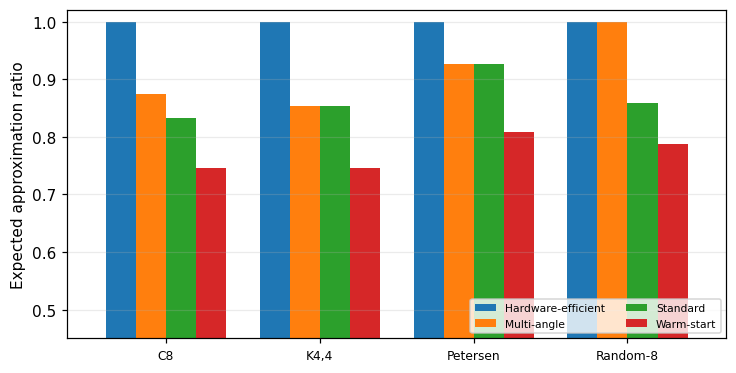

In [7]:
quality = results.pivot(index="graph", columns="ansatz", values="expectation_ratio")
axis = quality.plot(kind="bar", figsize=(6.8, 3.5), width=0.78)
axis.set_ylim(0.45, 1.02)
axis.set_ylabel("Expected approximation ratio")
axis.set_xlabel("")
axis.legend(fontsize=7, ncol=2, loc="lower right")
axis.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

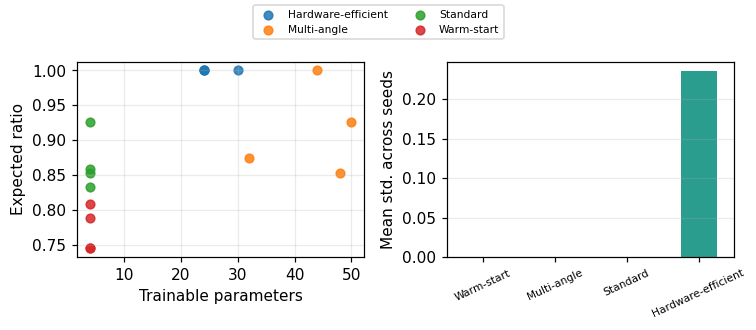

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0))

for ansatz, group in results.groupby("ansatz"):
    axes[0].scatter(
        group["parameters"], group["expectation_ratio"],
        s=32, label=ansatz, alpha=0.85,
    )
axes[0].set_xlabel("Trainable parameters")
axes[0].set_ylabel("Expected ratio")
axes[0].grid(alpha=0.25)

stability = results.groupby("ansatz")["seed_std"].mean().sort_values()
stability.plot(kind="bar", ax=axes[1], color="#2a9d8f")
axes[1].set_ylabel("Mean std. across seeds")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", labelrotation=25, labelsize=7)
axes[1].grid(axis="y", alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=7, ncol=2, loc="upper center")
plt.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

## 6. Automatic summary

下面分别找出每个图中期望近似比最高的 Ansatz，并计算各 Ansatz 的平均质量、参数数和稳定性。

In [9]:
winners = results.loc[results.groupby("graph")["expectation_ratio"].idxmax(), [
    "graph", "ansatz", "expectation_ratio", "parameters",
    "entangling_gates", "optimal_probability",
]]

average_summary = (
    results.groupby("ansatz")
    .agg(
        mean_ratio=("expectation_ratio", "mean"),
        mean_parameters=("parameters", "mean"),
        mean_entanglers=("entangling_gates", "mean"),
        mean_seed_std=("seed_std", "mean"),
        median_runtime_s=("median_runtime_s", "median"),
    )
    .sort_values("mean_ratio", ascending=False)
)

print("Best Ansatz for each graph")
display(winners.round(4).reset_index(drop=True))
print("Average across graph families")
display(average_summary.round(4))

Best Ansatz for each graph


,graph,ansatz,expectation_ratio,parameters,entangling_gates,optimal_probability
0,C8,Hardware-efficient,1.0,24,16,1.0
1,"K4,4",Hardware-efficient,1.0,24,32,1.0
2,Petersen,Hardware-efficient,1.0,30,30,1.0
3,Random-8,Hardware-efficient,1.0,24,28,1.0


Average across graph families


,mean_ratio,mean_parameters,mean_entanglers,mean_seed_std,median_runtime_s
ansatz,,,,,
Hardware-efficient,1.0000,25.5,26.5,0.2357,0.0092
Multi-angle,0.9135,43.5,53.0,0.0000,0.0187
Standard,0.8678,4.0,53.0,0.0000,0.0111
Warm-start,0.7716,4.0,53.0,0.0000,0.0006


## 7. Conclusions for Question 9(b)

1. **Standard QAOA 是必要基线。** 它只使用 $2p$ 个参数，通常训练稳定，特别适合高度对称的图。
2. **Multi-angle QAOA 提高了表达能力，但并非免费。** 它不增加 QAOA cost layer 的 CNOT 数，却将参数数增加到 $p(|E|+|V|)$；是否值得取决于图的不规则性和优化预算。
3. **Warm-start 的优势来自经典信息。** 它经常在较浅深度下提高期望值或最优解概率，但若经典初始解本身已经最优，这不能被解释为量子优势。
4. **Hardware-efficient Ansatz 的纠缠门较少。** 但其参数更多，而且不保证像标准 QAOA 一样直接遵循 MaxCut Hamiltonian，因此可能需要更多优化或更好的层结构。
5. **不存在对所有图都最优的 Ansatz。** 最终选择应同时考虑期望近似比、最优解概率、参数数、纠缠门数、深度和跨 seed 稳定性，而不能只看一次采样得到的最好 bitstring。

### Recommended next experiment

在相同图上加入 finite-shot objective 与噪声模型，重新比较 Standard、Multi-angle 和 Warm-start。精确期望值下表现最好的 Ansatz，在 shot noise 或真实硬件上未必仍然最好。